In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
sys.path.append(os.path.abspath('..'))
from src.wiserep import plot_spectra

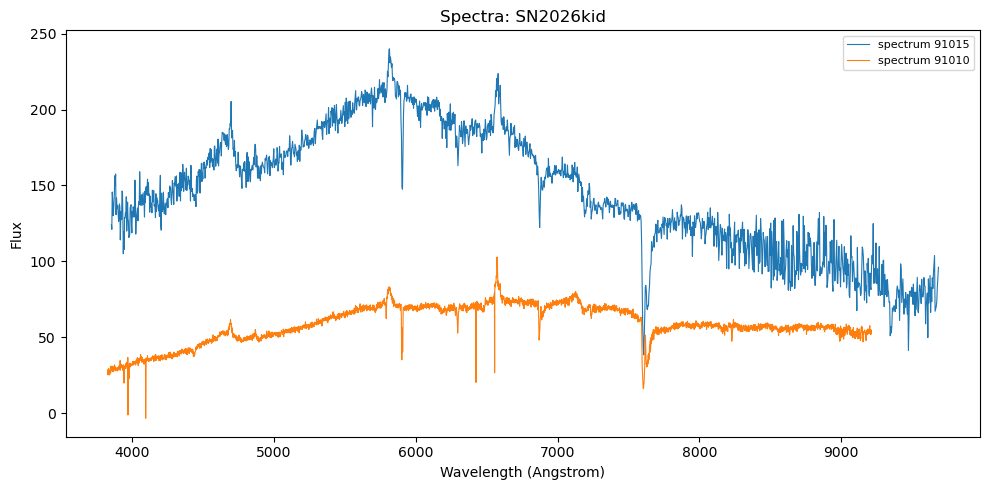

In [2]:
target_name='SN2026kid'
filedir=f'../output/{target_name}/spectrum/'
filepath=list(Path(filedir).glob('*.ascii'))

plot_spectra(filepath, target_name, jupyter=True)


In [3]:
# 1. 强制 TensorFlow 仅使用 CPU，避免显存溢出导致内核崩溃
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# 2. 屏蔽 TensorFlow 底层烦人的 C++ 警告信息
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import astrodash

print("正在启动 DASH... (已开启纯 CPU 安全模式)")

# ========== 填入宿主星系信息 ==========
# 如果你通过查阅文献或数据库（如 NED）知道了宿主星系的红移
# 比如 NGC 5907 的红移大约是 0.00222
host_galaxy_z = 0.00222 

try:
    # 运行分类器
    classification = astrodash.Classify(
        filenames=[filepath[0]],  # 传入你的光谱文件路径列表
        knownZ=host_galaxy_z,  # <--- 传入已知红移，计算量骤减，准确率大增！
        smooth=6               # 适度平滑光谱
    )
    
    # 获取最佳匹配
    best_fits, rejected_fits = classification.list_best_matches()
    
    if best_fits:
        best_match = best_fits[0]
        sn_name = best_match[0]        
        sn_type = best_match[1]        
        sn_age = best_match[2]         
        sn_z = best_match[3]           
        
        print("-" * 40)
        print(f"🎯 DASH 最终分类结果 (基于已知红移 z={host_galaxy_z}):")
        print(f"超新星类型 (Type): {sn_type}")
        print(f"演化阶段 (Age): {sn_age} days (相对于光变极大期)")
        print(f"拟合红移 (z): {sn_z:.4f} (应与宿主星系红移接近)")
        print(f"最匹配的标准模板: {sn_name}")
        print("-" * 40)
        
        # 强烈建议画出对比图，这是放在你 PPT 里的绝杀图表！
        # 会在本地生成一个 PDF 或者弹窗展示拟合效果
        classification.plot_with_gui() 
    else:
        print("未找到合适的匹配模板。")

except Exception as e:
    print(f"❌ DASH 运行过程中发生 Python 级错误: {e}")

: 

In [ ]:
# 假设前一步 DASH 告诉你这是一颗 Ia 型超新星 (有极强的 Si II 吸收线)
# 或者是一颗 II 型超新星 (有极强的 H-alpha 吸收线)

# 1. 选择我们要测量的特征谱线 (静止波长)
# 如果是 Ia 型，取消注释这行：
# rest_wave = 6355.0  # 硅离子 Si II 的特征波长
# 如果是 II 型，取消注释这行：
rest_wave = 6562.8  # 氢的巴耳末系 H-alpha 波长

c = 299792.458 # 光速 (km/s)

# 2. 去除红移 (De-redshift)
# 利用 Cell 2 中拟合出来的红移 sn_z，把观测波长还原到超新星的静止参考系
wave_rest_frame = wave / (1 + sn_z)

# 3. 利用 NumPy 切片寻找吸收谷 (Absorption Trough)
# 膨胀速度通常在 5000 ~ 20000 km/s，对应的波长蓝移大约在 100 ~ 400 埃
search_min = rest_wave - 500 # 搜索下限
search_max = rest_wave       # 搜索上限

# 使用布尔索引 (NumPy的精髓) 截取特征谱线附近的数据
mask = (wave_rest_frame > search_min) & (wave_rest_frame < search_max)
local_wave = wave_rest_frame[mask]
local_flux = flux_smoothed[mask]

# 找到这段区间内流量最小的点 (即吸收线中心)
min_idx = np.argmin(local_flux)
obs_abs_wave = local_wave[min_idx]

# 4. 计算膨胀速度 (非相对论多普勒公式 v = c * Δλ / λ)
v_exp = c * (rest_wave - obs_abs_wave) / rest_wave

print(f"谱线静止波长: {rest_wave} A")
print(f"实际观测到的吸收谷波长: {obs_abs_wave:.1f} A")
print(f"🚀 结论：抛射物膨胀速度 v_exp = {v_exp:.0f} km/s")

# 5. 画个局部放大图展示成果
plt.figure(figsize=(8, 4))
plt.plot(local_wave, local_flux, 'b-', label='Smoothed Spectrum')
plt.axvline(rest_wave, color='red', linestyle='--', label='Rest Wavelength (Zero Velocity)')
plt.axvline(obs_abs_wave, color='green', linestyle=':', label='Observed Minimum')
plt.title(f'P-Cygni Absorption Feature (v = {v_exp:.0f} km/s)')
plt.xlabel('Rest-frame Wavelength ($\AA$)')
plt.legend()
plt.show()